# Neural signal forecasting v9
## time-aware gated axial attention + temporal conv + GCN

## What's New in v9 (Spike-Aware Modeling)
- **Conservative spike awareness:** affi shows occasional upward jumps mid-horizon; v9 adds a light change head to catch these without destabilizing the base value forecast.
- **Fix for mid-horizon jump misses:** v9 explicitly models delta y and up-weights large changes so sudden rises are less likely to be smoothed away.
- **Variance control:** the change loss is weighted with a small lambda, keeping the value head behavior close to v7 while improving jump recall.


In [1]:
# Build dataloader
import torch
import numpy as np
import os
from model_v14 import NFSTNDTModelV14
from utils import *
from trainer import Trainer

def _instance_norm_feature0(xb, init_steps=10):
    x0 = xb[:, :init_steps, :, 0]
    mu = x0.mean(dim=1, keepdim=True)
    sigma = x0.std(dim=1, keepdim=True, unbiased=False) + 1e-6
    xb = xb.clone()
    xb[:, :, :, 0] = (xb[:, :, :, 0] - mu) / sigma
    return xb, mu, sigma


def _prepare_data_with_instnorm(self, data):
    data, mu, sigma = _instance_norm_feature0(data, init_steps=self.init_steps)
    # Keep per-batch params for optional inverse transforms.
    self.last_mu = mu
    self.last_sigma = sigma
    if self.forecasting_mode == 'one_step':
        input_data = data[:, :-1, :, :]
        target_data = data[:, 1:, :, 0]
    elif self.forecasting_mode == 'multi_step':
        future_step = data.shape[1] - self.init_steps
        input_data = torch.cat([
            data[:, :self.init_steps, :, :],
            torch.repeat_interleave(data[:, self.init_steps-1:self.init_steps, :, :], future_step, dim=1)
        ], dim=1)
        target_data = data[:, self.init_steps:, :, 0]
    else:
        raise ValueError(f"Unknown forecasting_mode: {self.forecasting_mode}")
    return input_data, target_data


Trainer.prepare_data = _prepare_data_with_instnorm


input_dir = './'

## What changed in v4
- fix input issue: remove adj from input of forward()

## What's New in v5 Compared to v4
- **New inputs:** optional timestamp tensor `t` with shape `(B, T)` alongside signal `x` (still `(B, T, C, F)`).
- **New modeling assumption:** irregular sampling is allowed; the model uses `delta_t` computed internally from `t`.
- **Architectural change:** time features are encoded (Time2Vec + `delta_t`) and concatenated to signal features *before* the axial attention backbone.
- **Why this helps:** time-awareness reduces the fixed-interval assumption and improves robustness when sampling is uneven or when time context matters.

### Time inputs in this notebook
If your dataset does not include timestamps, we generate a synthetic monotonic `t` using `torch.arange(T)` so the pipeline remains backward compatible. When `delta_t` is constant, v5 behaves like v4 with a richer positional bias.


## Time-aware inputs (v5)
- We construct a timestamp tensor `t` with shape `(B, T)` using `torch.arange(T)` when real timestamps are unavailable.
- The v5 model computes `delta_t = t[:, i] - t[:, i-1]` internally.
- Time2Vec is used inside `model_v5.py` to encode time before the backbone.


In [2]:
# parameters:
dataset_name = 'beignet'
# dataset_name = 'affi'
if dataset_name == 'beignet':
  num_channels = 89
else:
  num_channels = 239

batch_size = 16
num_epochs = 100
learning_rate = 1e-4
hidden_size = 256
n_heads=4
n_layers=3
dropout=0.1
input_size = num_channels

# --- Pseudo-session-aware split (segment-aware train/val, temporal test) ---
# Data is assumed to be ordered in time; we avoid random shuffling here.
raw = np.load(f'dataset/train_data_{dataset_name}.npz')['arr_0']
num_total = len(raw)

test_start = int(num_total * 0.9)
trainval = raw[:test_start]
test_data = raw[test_start:]

# --- Pseudo-session signature (first 10 timesteps, feature 0) ---
init_steps = 10
x_win = trainval[:, :init_steps, :, 0]
mean_abs = np.mean(np.abs(x_win), axis=(1, 2))
std = np.std(x_win, axis=(1, 2))
sig = np.stack([mean_abs, std], axis=1)

# --- Conservative change-point detection ---
diff = np.linalg.norm(sig[1:] - sig[:-1], axis=1)
med = np.median(diff)
mad = np.median(np.abs(diff - med))
k = 5.0
threshold = med + k * mad

candidate = np.where(diff > threshold)[0] + 1
min_seg_len = max(50, int(0.01 * len(trainval)))

boundaries = []
last = 0
for idx in candidate:
    if idx - last < min_seg_len:
        continue
    boundaries.append(int(idx))
    last = idx

if boundaries and (len(trainval) - boundaries[-1] < min_seg_len):
    boundaries.pop()

bounds = [0] + boundaries + [len(trainval)]
segment_lengths = [bounds[i + 1] - bounds[i] for i in range(len(bounds) - 1)]
num_segments = len(segment_lengths)

segment_ids = np.zeros(len(trainval), dtype=int)
for i in range(num_segments):
    segment_ids[bounds[i]:bounds[i + 1]] = i

# --- Segment-aware train/val split (keep temporal test) ---
target_val = int(num_total * 0.1)
val_segments = []
running = 0
for i in range(num_segments - 1, -1, -1):
    if running >= target_val:
        break
    val_segments.append(i)
    running += segment_lengths[i]
val_segments = sorted(val_segments)

val_mask = np.isin(segment_ids, val_segments)
train_data = trainval[~val_mask]
val_data = trainval[val_mask]

print(f"Detected {num_segments} segments")
print(f"Segment lengths: {segment_lengths}")
print(f"Validation segments: {val_segments}")
print(f"Split sizes: train {len(train_data)}, val {len(val_data)}, test {len(test_data)}")


Detected 5 segments
Segment lengths: [100, 110, 104, 200, 116]
Validation segments: [4]
Split sizes: train 514, val 116, test 70


In [3]:
from torch.utils.data import DataLoader
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# Dataset / Dataloader
# ============================================================
train_ds = NeuroForcastDataset(train_data, use_graph=False)
np.savez(
    f'train_data_average_std_{dataset_name}.npz',
    average=train_ds.average,
    std=train_ds.std
)

test_ds = NeuroForcastDataset(
    test_data,
    use_graph=False,
    average=train_ds.average,
    std=train_ds.std
)
val_ds = NeuroForcastDataset(
    val_data,
    use_graph=False,
    average=train_ds.average,
    std=train_ds.std
)

train_data_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_data_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
val_data_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

# adj_matrix = compute_adj_matrix(train_data, threshold=0.1).to(torch.device('cuda'))

# ============================================================
# Time handling (unchanged)
# ============================================================
def build_time_tensor(x):
    # x: (B, T, C, F) -> t: (B, T)
    t = torch.arange(x.shape[1], device=x.device, dtype=x.dtype)
    return t.unsqueeze(0).repeat(x.shape[0], 1)

class TimeAwareWrapper(nn.Module):
    """
    Wraps the v10 model so the existing Trainer can call model(x).
    v10 operates on per-channel sequences: (B*C, T, F).
    """
    def __init__(self, base_model, quantiles):
        super().__init__()
        self.base_model = base_model
        self.quantiles = quantiles

    def forward(self, x, t=None):
        # x: (B, T, C, F)
        if t is None:
            t = build_time_tensor(x)

        B, T, C, F = x.shape

        x_flat = x.permute(0, 2, 1, 3).contiguous().view(B * C, T, F)
        t_flat = t.unsqueeze(1).repeat(1, C, 1).view(B * C, T)

        out = self.base_model(x_flat, t_flat)
        y_pred = out["y_pred"]   # (B*C, T, Q)
        dy_pred = out["dy_pred"] # (B*C, T)

        Q = y_pred.shape[-1]
        y_pred = y_pred.view(B, C, T, Q).permute(0, 2, 1, 3).contiguous()
        dy_pred = dy_pred.view(B, C, T).permute(0, 2, 1).contiguous()

        dy_pred = dy_pred.unsqueeze(-1)
        return torch.cat([y_pred, dy_pred], dim=-1)  # (B, T, C, Q+1)

# ============================================================
# Model
# ============================================================
quantiles = [0.1, 0.5, 0.9]

# base_model = NFSTNDTModelV10(
#     input_size=9,
#     hidden_size=hidden_size,
#     n_heads=n_heads,
#     n_layers=n_layers,
#     dropout=dropout,
#     num_features=9,
#     use_time2vec=True,
#     time2vec_k=8,
#     use_delta_t=True,
#     quantiles=quantiles
# ).to(torch.device('cuda'))

# model = TimeAwareWrapper(base_model, quantiles).to(torch.device('cuda'))

print("Computing Adjacency Matrix...")
adj_matrix = compute_adj_matrix(train_data, threshold=0.3).to(torch.device('cuda'))
print(f"Adjacency Matrix shape: {adj_matrix.shape}")

model = NFSTNDTModelV14(
    input_size=9,
    hidden_size=256,   # v12 參數較少，可以用大一點的 hidden_size
    n_heads=4,
    n_layers=3,
    dropout=0.1,
    num_features=9,
    use_time2vec=True,
    time2vec_k=8,
    use_delta_t=True,
    quantiles=[0.1, 0.5, 0.9],
    adj=adj_matrix     # 【關鍵】注入矩陣
).to(torch.device('cuda'))

# ============================================================
# Spike threshold (unchanged logic)
# ============================================================
f0 = train_data[..., 0]  # (N,T,C)
dy = f0[:, 1:, :] - f0[:, :-1, :]
abs_dy = np.abs(dy.reshape(-1))
# tau = float(np.percentile(abs_dy, 90))
tau =  0.1572
print(f"Spike threshold tau (90th percentile of |delta y|): {tau:.6f}")

spike_weight  = 10.0
lambda_change = 0.2

# ============================================================
# v10.1 Spike-aware + Quantile-consistent loss
# ============================================================
def pinball_loss(y_hat, y, q):
    e = y - y_hat
    return torch.maximum(q * e, (q - 1.0) * e)

def quantile_order_penalty(q10, q50, q90):
    return (
        F.relu(q10 - q50).mean() +
        F.relu(q50 - q90).mean()
    )

change_loss_fn = torch.nn.L1Loss(reduction="none")

def spike_aware_loss_v14(pred_tensor, target, init_steps=10):
    """
    pred_tensor: (B, T, C, Q+1) -> 最後一維是 [q10, q50, q90, dy]
    target: (B, T, C)
    """
    # 1. 拆解 Output
    Q = 3 
    y_pred = pred_tensor[..., :Q]   # (B, T, C, 3)
    dy_pred = pred_tensor[..., Q]   # (B, T, C)
    y_true = target                 # (B, T, C)
    
    # 2. 計算真實變化量 dy_true
    dy_true = y_true[:, 1:, :] - y_true[:, :-1, :]
    # 補回長度 (B, T, C)
    dy_true = torch.cat([dy_true[:, :1, :], dy_true], dim=1)
    
    # 3. 【核心修正】製作權重遮罩 (Weight Mask)
    # 找出真實發生劇烈變化的地方
    abs_dy_true = torch.abs(dy_true)
    # 如果變化量 > tau，權重=10，否則=1
    weights = torch.where(abs_dy_true > tau, spike_weight, 1.0)

    # --- 【新增】銳利度懲罰 (Sharpness/Width Loss) ---
    # 計算區間寬度
    width = y_pred[..., 2] - y_pred[..., 0] # q90 - q10
    # 我們希望寬度越小越好，但不能小於 0
    # 權重建議 0.1 ~ 0.5，視情況調整
    loss_width = torch.mean(width) 
    
    # 4. 防崩潰機制 (保持不變)
    loss_crossing = torch.mean(torch.relu(y_pred[..., 0] - y_pred[..., 1])) + \
                    torch.mean(torch.relu(y_pred[..., 1] - y_pred[..., 2]))

    # 5. Quantile Loss (加上權重)
    q_losses = []
    for k, q in enumerate([0.1, 0.5, 0.9]):
        e = y_true - y_pred[..., k]
        q_loss_elementwise = torch.maximum(q * e, (q - 1.0) * e)
        
        # 【修正點】在這裡乘上權重
        q_loss_weighted = q_loss_elementwise * weights 
        q_losses.append(q_loss_weighted.mean())
        
    loss_quant = sum(q_losses)

    # 6. Change Loss (加上權重)
    # 使用 reduction='none' 的 L1 Loss 算出每個點的誤差
    change_loss_elementwise = change_loss_fn(dy_pred, dy_true)
    
    # 【修正點】在這裡乘上權重
    loss_change = (change_loss_elementwise * weights).mean()

    # 7. 總 Loss
    # return loss_quant + lambda_change * loss_change + 10.0 * loss_crossing
    return loss_quant + 0.2 * loss_change + 10.0 * loss_crossing + 0.1 * loss_width

def initialize_quantile_bias(model):
    """
    將輸出層的 bias 設定為標準常態分佈的分位數
    q10 ~ -1.28, q50 ~ 0.0, q90 ~ 1.28
    這樣模型一開始就會輸出大約 80% 的覆蓋率，避免崩潰。
    """
    # 假設 quantiles = [0.1, 0.5, 0.9]
    # 對應的標準常態分佈數值 (Standard Normal Quantiles)
    # 你可以稍微設大一點，確保一開始夠寬
    init_bias = torch.tensor([-1.0, 0.0, 1.0]).to(model.value_head.weight.device)
    
    # 強制覆寫 bias
    with torch.no_grad():
        model.value_head.bias.copy_(init_bias)
        # 讓 weight 一開始小一點，主要靠 bias 輸出
        model.value_head.weight.data *= 0.01 

    print("Quantile Head Bias Initialized to [-1.0, 0.0, 1.0]")

def force_init_bias_mild(model):
    print("Initializing Quantile Bias (Mild)...")
    with torch.no_grad():
        # 改為 [-0.5, 0, 0.5] 或 [-0.8, 0, 0.8]
        # 讓模型一開始的 Coverage 大約在 50%~60%，逼它自己去學剩下的
        model.value_head.bias.copy_(torch.tensor([-0.6, 0.0, 0.6]).to(torch.device('cuda')))
        model.value_head.weight.data.normal_(0, 0.01)

# ============================================================
# Optim / Scheduler
# ============================================================
# loss_fn = lambda y_hat, y_true: spike_aware_loss_v10_1(y_hat, y_true, init_steps=10)
loss_fn = lambda y_hat, y_true: spike_aware_loss_v14(y_hat, y_true, init_steps=10)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-2
)

lambda1 = lambda epoch: 0.95 ** (epoch // 20)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda1
)

# ============================================================
# Trainer
# ============================================================
save_path = f'./model_{dataset_name}_v14.pth'

trainer = Trainer(
    model=model,
    train_data_loader=train_data_loader,
    test_data_loader=test_data_loader,
    val_data_loader=val_data_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=torch.device('cuda'),
    scheduler=scheduler,
    forecasting_mode='multi_step',
    init_steps=10,
    save_path=save_path,
    ckpt_path=None,
    max_grad_norm=1.0,
    validate_every=1,
    save_best=True
)
initialize_quantile_bias(model)
force_init_bias_mild(model)

trainer.train(num_epochs)
print("Best val:", trainer.best_val)
print("Best weight path:", save_path)


Computing Adjacency Matrix...


Epoch 1/100:   0%|          | 0/33 [00:00<?, ?it/s, train_loss=17.202179, lr=3.00e-04]

Adjacency Matrix shape: torch.Size([89, 89])
Spike threshold tau (90th percentile of |delta y|): 0.157200
Quantile Head Bias Initialized to [-1.0, 0.0, 1.0]
Initializing Quantile Bias (Mild)...


Epoch 2/100:   6%|▌         | 2/33 [00:00<00:02, 13.06it/s, train_loss=27.006893, lr=3.00e-04]

Epoch 000 | lr=3.000000e-04 | Train=14.676244 | Val=15.469838
Saving keys: ['adj', 'time2vec.w0', 'time2vec.b0', 'time2vec.w', 'time2vec.b', 'in_proj.weight', 'in_proj.bias', 'encoder.layers.0.self_attn.in_proj_weight', 'encoder.layers.0.self_attn.in_proj_bias', 'encoder.layers.0.self_attn.out_proj.weight', 'encoder.layers.0.self_attn.out_proj.bias', 'encoder.layers.0.linear1.weight', 'encoder.layers.0.linear1.bias', 'encoder.layers.0.linear2.weight', 'encoder.layers.0.linear2.bias', 'encoder.layers.0.norm1.weight', 'encoder.layers.0.norm1.bias', 'encoder.layers.0.norm2.weight', 'encoder.layers.0.norm2.bias', 'encoder.layers.1.self_attn.in_proj_weight']
[BEST] Saved to ./model_beignet_v14.pth | best_val=15.469838


...

Epoch 097 | lr=2.443519e-04 | Train=12.096223 | Val=14.110917


Epoch 100/100:   6%|▌         | 2/33 [00:00<00:02, 12.90it/s, train_loss=24.740383, lr=2.44e-04]

Epoch 098 | lr=2.443519e-04 | Train=12.017909 | Val=14.256121


Epoch 100/100: 100%|██████████| 33/33 [00:02<00:00, 13.21it/s, train_loss=11.873718, lr=2.44e-04]
                                                                      

Epoch 099 | lr=2.321343e-04 | Train=11.873718 | Val=14.062510
Best val: 13.620900869369507
Best weight path: ./model_beignet_v14.pth


## What's New in v6 Compared to v5
- **Why point forecasting is insufficient:** v5 produces a single trajectory, but real neural signals are noisy and multi-modal; a single point hides ambiguity and can be overconfident when the test distribution shifts.
- **What uncertainty means here:** for each future time and channel, multiple plausible outcomes exist due to measurement noise and changing dynamics.
- **How v6 models predictive uncertainty:** v6 predicts multiple **quantiles** of the target distribution (e.g., 0.1, 0.5, 0.9) using a pinball loss. This yields a median forecast plus uncertainty bands.
- **Why this improves robustness under distribution shift:** quantile outputs avoid overconfident point estimates and provide calibrated ranges that remain useful even when patterns differ from training.

## Output shape (v6)
- Model output: `y_hat` has shape `(B, T, C, Q)` where `Q = len(quantiles)`.
- For multi-step forecasting, the trainer compares `y_hat[:, init_steps:, :, :]` against target `(B, H, C)`.

## What's New in v7 Compared to v6
- **Why autoregressive forecasting is problematic:** rolling predictions forward compounds errors and can drift quickly when the data distribution shifts.
- **How direct multi-horizon prediction improves stability:** v7 predicts the entire future window in a single forward pass, avoiding step-by-step error accumulation.
- **Why time-based evaluation is necessary:** random splits leak future patterns into training; strict temporal splits better match real deployment.
- **How v7 better measures generalization:** per-horizon metrics and interval coverage expose where the model degrades as the horizon grows.

## Direct multi-horizon forecasting (v7)
- Forecast horizon `H = T - init_steps` is predicted directly in one pass (no autoregressive rollout).
- Model output for evaluation: `y_hat_future` has shape `(B, H, C, Q)`.
- **Backward compatibility:** when `H = 1` and horizon weights are uniform, v7 reduces to the v6 objective.

## Temporal evaluation protocol (v7)
- **Train:** earliest 80% of samples
- **Val:** next 10%
- **Test:** final 10% (most recent)
- This mirrors real-world deployment where only past data is available for training.

## Spike-aware loss (v9)
- Compute delta y on the target feature and mark spikes where |delta y| > tau.
- tau is estimated from training data (high-percentile of |delta y|), so thresholds are data-driven.
- Spike horizons receive an extra loss weight to prioritize rare jumps.


Loaded keys: ['adj', 'time2vec.w0', 'time2vec.b0', 'time2vec.w', 'time2vec.b', 'in_proj.weight', 'in_proj.bias', 'encoder.layers.0.self_attn.in_proj_weight', 'encoder.layers.0.self_attn.in_proj_bias', 'encoder.layers.0.self_attn.out_proj.weight', 'encoder.layers.0.self_attn.out_proj.bias', 'encoder.layers.0.linear1.weight', 'encoder.layers.0.linear1.bias', 'encoder.layers.0.linear2.weight', 'encoder.layers.0.linear2.bias', 'encoder.layers.0.norm1.weight', 'encoder.layers.0.norm1.bias', 'encoder.layers.0.norm2.weight', 'encoder.layers.0.norm2.bias', 'encoder.layers.1.self_attn.in_proj_weight']
Per-horizon MSE (median): [0.082571 0.242072 0.241918 0.263861 0.293118 0.335162 0.426348 0.434952
 0.324014 0.288341]
Per-horizon MAE (median): [0.248705 0.448423 0.440591 0.468019 0.50064  0.540874 0.619805 0.621625
 0.517691 0.47985 ]
Per-horizon 80% interval coverage (q10-q90): [0.958 0.995 0.998 0.997 0.997 0.997 0.996 0.996 0.996 0.997]
Per-horizon spike recall (upward jumps): [0.41  0.333 0

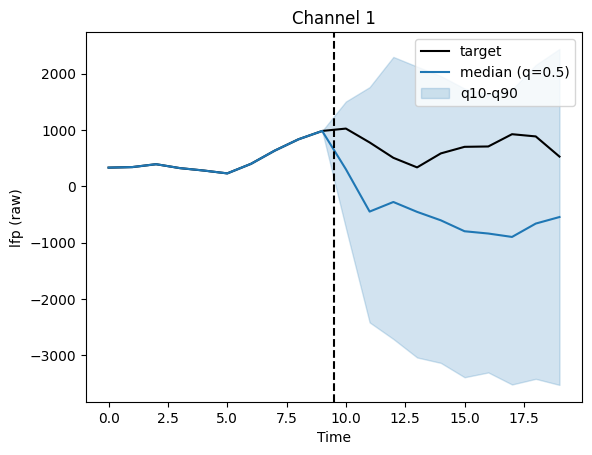

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt

INIT_STEPS = 10
DEVICE = torch.device("cuda")

# --- Load BEST model ---
quantiles = [0.1, 0.5, 0.9]
base_model_test = NFSTNDTModelV14(
    input_size=9,
    hidden_size=hidden_size,
    n_heads=n_heads,
    n_layers=n_layers,
    dropout=dropout,
    num_features=9,
    use_time2vec=True,
    time2vec_k=8,
    use_delta_t=True,
    quantiles=quantiles,
    adj = adj_matrix
).to(DEVICE)
# model_test = TimeAwareWrapper(base_model_test, quantiles).to(DEVICE)
# model_test.load_state_dict(torch.load(f'./model_{dataset_name}_v14.pth', map_location="cpu"))
state = torch.load(f'./model_{dataset_name}_v14.pth', map_location="cpu")
print("Loaded keys:", list(state.keys())[:20])
assert not any(k.startswith("base_model.") for k in state.keys())
assert not any(k.startswith("head.") for k in state.keys())

base_model_test.load_state_dict(state, strict=True)

base_model_test.eval()

# --- De-normalization helpers (feature 0 only) ---
stats = np.load(f'train_data_average_std_{dataset_name}.npz')
avg_cf = stats['average']  # (1, C*F)
std_cf = stats['std']
num_feats = avg_cf.shape[1] // num_channels
avg_f0 = avg_cf.reshape(1, num_channels, num_feats)[..., 0]
std_f0 = std_cf.reshape(1, num_channels, num_feats)[..., 0]
combine_max = avg_f0 + 4 * std_f0
combine_min = avg_f0 - 4 * std_f0

def denorm_feature0(x, channel_idx=None):
    x_np = x.detach().cpu().numpy() if torch.is_tensor(x) else x
    if x_np.shape[-1] == num_channels:
        return ((x_np + 1) / 2) * (combine_max - combine_min) + combine_min
    if channel_idx is None:
        raise ValueError("channel_idx required for single-channel inputs")
    cmax = combine_max[..., channel_idx]
    cmin = combine_min[..., channel_idx]
    return ((x_np + 1) / 2) * (cmax - cmin) + cmin

def prepare_input_masked(data, init_steps=INIT_STEPS):
    # data: (B,20,C,F)
    future = data.shape[1] - init_steps
    x_in = torch.cat([
        data[:, :init_steps, :, :],
        data[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)
    y_future = data[:, init_steps:, :, 0]  # (B,10,C) feature0 target
    return x_in, y_future

def prepare_input_masked_4d(data, init_steps=10):
    # data: (B, 20, C, 9)
    # 我們需要把未來 (10~19步) 的數值遮住 (用第9步重複填充)
    # 但要保留所有 9 個特徵
    
    # 1. 取出前 10 步 (B, 10, C, 9)
    obs = data[:, :init_steps, :, :]
    
    # 2. 取出第 9 步 (B, 1, C, 9)
    last_obs = data[:, init_steps-1:init_steps, :, :]
    
    # 3. 複製第 9 步來填充未來 10 步
    future_mask = last_obs.repeat(1, data.shape[1] - init_steps, 1, 1)
    
    # 4. 拼接回 (B, 20, C, 9)
    x_in = torch.cat([obs, future_mask], dim=1)
    
    # 5. 取出真實的未來 Feature 0 (LFP) 作為 Target (B, 10, C)
    y_future = data[:, init_steps:, :, 0]
    
    return x_in, y_future

@torch.no_grad()
def eval_metrics_per_horizon(model, loader, device, init_steps=10, spike_tau=None):
    model.eval()
    
    # 儲存每個時間步 (Horizon 1~10) 的誤差
    # Shape: (N_samples, 10)
    err_sq_list = []
    abs_err_list = []
    cov_hit_list = []
    
    # 用於 Spike Recall 計算
    true_spikes_list = []
    pred_spikes_list = []

    all_preds = []
    all_tgts = []

    for batch in loader:
        batch = batch.to(device) # (B, 20, C, 9)
        
        # 1. 準備 4D 輸入 (遮蔽未來)
        x_in, y_true_future = prepare_input_masked_4d(batch, init_steps) # y_true_future: (B, 10, C)
        
        # 2. 建立時間張量
        t_in = torch.arange(x_in.shape[1], device=device).unsqueeze(0).repeat(x_in.shape[0], 1)
        
        # 3. 模型預測
        out = model(x_in, t_in)
        
        # 4. 處理回傳格式 (Dict vs Tensor)
        if isinstance(out, dict):
            y_pred_full = out['y_pred'] # (B, 20, C, Q)
        else:
            y_pred_full = out[..., :-1] # (B, 20, C, Q)
            
        # 取出未來 10 步 (B, 10, C, Q)
        y_pred_future = y_pred_full[:, init_steps:, :, :]
        
        # 假設 Q=3: [q10, q50, q90]
        y_q10 = y_pred_future[..., 0]
        y_q50 = y_pred_future[..., 1]
        y_q90 = y_pred_future[..., 2]

        # --- A. 蒐集 MSE/MAE 數據 ---
        # 誤差: (B, 10, C)
        err = y_true_future - y_q50
        err_sq_list.append(torch.mean(err ** 2, dim=2).cpu().numpy()) # (B, 10) - 對 Channel 平均
        abs_err_list.append(torch.mean(torch.abs(err), dim=2).cpu().numpy())

        # --- B. 蒐集 Coverage 數據 ---
        # 判斷是否在區間內: (B, 10, C) -> Boolean
        hit = (y_true_future >= y_q10) & (y_true_future <= y_q90)
        cov_hit_list.append(torch.mean(hit.float(), dim=2).cpu().numpy())

        # --- C. 蒐集 Spike Recall 數據 ---
        if spike_tau is not None:
            # 計算真實值的變化量 (Diff)
            # 注意：第 1 步的變化是 y_future[0] - x_in[最後一步]
            # 為了方便，我們這裡只計算未來 10 步內部的變化
            # (B, 9, C)
            dy_true = y_true_future[:, 1:, :] - y_true_future[:, :-1, :]
            dy_pred = y_q50[:, 1:, :] - y_q50[:, :-1, :]
            
            # 判斷是否為 Spike (大於門檻)
            is_spike_true = torch.abs(dy_true) > spike_tau
            
            # 判斷模型是否也預測出同方向的 Spike (或者至少幅度夠大)
            # 這裡定義寬鬆一點：只要預測的變化量 > 0.5 * tau 且方向一致就算抓到
            is_spike_pred = (torch.abs(dy_pred) > (spike_tau * 0.5)) & \
                            (torch.sign(dy_pred) == torch.sign(dy_true))
            
            true_spikes_list.append(is_spike_true.cpu().numpy())
            pred_spikes_list.append(is_spike_pred.cpu().numpy())

        # 儲存原始預測以便回傳 (只存 q50)
        all_preds.append(y_q50.cpu().numpy())
        all_tgts.append(y_true_future.cpu().numpy())

    # --- 整合所有 Batch ---
    # axis=0 是 Batch 維度
    mse_per_horizon = np.concatenate(err_sq_list, axis=0).mean(axis=0) # (10,)
    mae_per_horizon = np.concatenate(abs_err_list, axis=0).mean(axis=0) # (10,)
    cov_per_horizon = np.concatenate(cov_hit_list, axis=0).mean(axis=0) # (10,)
    
    # Spike Recall 計算
    # 我們需要把所有 batch 的所有 channel 攤平來算 recall
    if spike_tau is not None and len(true_spikes_list) > 0:
        all_true_spikes = np.concatenate(true_spikes_list, axis=0) # (N, 9, C)
        all_pred_spikes = np.concatenate(pred_spikes_list, axis=0) # (N, 9, C)
        
        recall_per_horizon = []
        # 對每一步 (1~9) 計算 Recall
        for t in range(all_true_spikes.shape[1]):
            true_mask = all_true_spikes[:, t, :]
            pred_mask = all_pred_spikes[:, t, :]
            
            # 避免分母為 0
            if true_mask.sum() == 0:
                recall_per_horizon.append(0.0)
            else:
                recall = (true_mask & pred_mask).sum() / true_mask.sum()
                recall_per_horizon.append(recall)
        
        # 第 10 步沒有 diff，補 0 湊滿 10 個
        recall_per_horizon.append(0.0)
        recall_per_horizon = np.array(recall_per_horizon)
    else:
        recall_per_horizon = np.zeros(10)

    # 整理回傳
    all_preds_np = np.concatenate(all_preds, axis=0)
    all_tgts_np = np.concatenate(all_tgts, axis=0)
    
    return mse_per_horizon, mae_per_horizon, cov_per_horizon, recall_per_horizon, all_preds_np, all_tgts_np


# reuse tau from training stats
f0 = train_data[..., 0]
dy = f0[:, 1:, :] - f0[:, :-1, :]
abs_dy = np.abs(dy.reshape(-1))
# tau = float(np.percentile(abs_dy, 95))
tau =  0.1572

mse_h, mae_h, cov_h, spike_recall_h, pred_future_q, tgt_future = eval_metrics_per_horizon(
    base_model_test, test_data_loader, DEVICE, INIT_STEPS, spike_tau=tau
)
print("Per-horizon MSE (median):", np.round(mse_h, 6))
print("Per-horizon MAE (median):", np.round(mae_h, 6))
print("Per-horizon 80% interval coverage (q10-q90):", np.round(cov_h, 3))
print("Per-horizon spike recall (upward jumps):", np.round(spike_recall_h, 3))

# --- Plot one example (full 20 steps) with uncertainty band ---

@torch.no_grad()
def plot_channel_quantiles(model, data_loader, channel_idx=1, device=torch.device("cuda"), init_steps=10, denorm=True):
    model.eval()
    batch = next(iter(data_loader)).to(device)   # (B,20,C,F)

    # build masked input
    future = batch.shape[1] - init_steps
    x_in = torch.cat([
        batch[:, :init_steps, :, :],
        batch[:, init_steps-1:init_steps, :, :].repeat(1, future, 1, 1)
    ], dim=1)

    # model output
    t_in = build_time_tensor(x_in)
    out = model(x_in, t_in)  # (B,20,C,Q+1)
    Q = len(quantiles)
    y_hat_q = out[..., :Q]

    # enforce competition rule: first 10 steps are given
    y_hat_q[:, :init_steps, :, :] = batch[:, :init_steps, :, 0].unsqueeze(-1)

    # pick one sample
    y_true = batch[0, :, channel_idx, 0]
    y_q10 = y_hat_q[0, :, channel_idx, quantiles.index(0.1)]
    y_q50 = y_hat_q[0, :, channel_idx, quantiles.index(0.5)]
    y_q90 = y_hat_q[0, :, channel_idx, quantiles.index(0.9)]

    if denorm:
        y_true = denorm_feature0(y_true, channel_idx=channel_idx)
        y_q10 = denorm_feature0(y_q10, channel_idx=channel_idx)
        y_q50 = denorm_feature0(y_q50, channel_idx=channel_idx)
        y_q90 = denorm_feature0(y_q90, channel_idx=channel_idx)
        ylabel = "lfp (raw)"
    else:
        y_true = y_true.detach().cpu().numpy()
        y_q10 = y_q10.detach().cpu().numpy()
        y_q50 = y_q50.detach().cpu().numpy()
        y_q90 = y_q90.detach().cpu().numpy()
        ylabel = "lfp (normalized)"

    assert np.all(y_q10 <= y_q50), "Quantile violation: q10 > q50"
    assert np.all(y_q50 <= y_q90), "Quantile violation: q50 > q90"


    plt.figure()
    plt.plot(y_true, label="target", color="black")
    plt.plot(y_q50, label="median (q=0.5)", color="tab:blue")
    plt.fill_between(np.arange(len(y_q50)), y_q10, y_q90, color="tab:blue", alpha=0.2, label="q10-q90")
    plt.axvline(x=init_steps-0.5, color="black", linestyle="--")
    plt.title(f"Channel {channel_idx}")
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()


plot_channel_quantiles(base_model_test, test_data_loader, channel_idx=1)


In [5]:
# 取一個 batch
batch = next(iter(test_data_loader)).to(DEVICE)
x_in, y_true = prepare_input_masked_4d(batch)
t_in = torch.arange(20, device=DEVICE).unsqueeze(0).repeat(batch.shape[0], 1)

# 模型預測
base_model_test.eval()
with torch.no_grad():
    out = base_model_test(x_in, t_in)
    # out 是 (B, 20, C, 4) -> [q10, q50, q90, dy]

# 印出第一筆資料、第一個通道的未來 5 步預測
print("Sample Predictions (q10, q50, q90):")
print(out[0, 10:15, 0, :3].cpu().numpy())

print("\nSample Spike Pred (dy) vs True (dy):")
dy_pred = out[0, 10:15, 0, 3].cpu().numpy()
# 真實的 dy 需要從 y_true 計算
dy_true = (y_true[0, 1:6, 0] - y_true[0, 0:5, 0]).cpu().numpy()
print("Pred dy:", dy_pred)
print("True dy:", dy_true)

Sample Predictions (q10, q50, q90):
[[-0.5168735  -0.0319153   0.52251947]
 [-0.9163311  -0.05549263  0.8594303 ]
 [-1.4198818  -0.30045667  0.8896689 ]
 [-1.5696143  -0.37491712  0.8280145 ]
 [-1.6399727  -0.46315613  0.74130046]]

Sample Spike Pred (dy) vs True (dy):
Pred dy: [-0.3655552  -0.26399484 -0.2247393  -0.18117745 -0.0973742 ]
True dy: [-0.10684329 -0.13498987 -0.09113672  0.11853169  0.0708916 ]


In [6]:
# 抓一個 Batch 來看 dy 的數值分佈
batch = next(iter(test_data_loader)).to(DEVICE)
x_in, y_true = prepare_input_masked_4d(batch)
t_in = torch.arange(20, device=DEVICE).unsqueeze(0).repeat(batch.shape[0], 1)

base_model_test.eval()
with torch.no_grad():
    out = base_model_test(x_in, t_in)
    dy_pred = out[..., 3] # (B, 20, C)

# 看一下預測的變化量到底有多大
print("Max predicted dy:", dy_pred.max().item())
print("Mean predicted |dy|:", torch.abs(dy_pred).mean().item())
print("Spike Threshold (tau):", tau)

Max predicted dy: 1.44953191280365
Mean predicted |dy|: 0.22754575312137604
Spike Threshold (tau): 0.1572


In [7]:
# 從 DataLoader 或 Dataset 裡抓取已經 Normalize 過的數據
# 假設 train_ds 是已經建立好的 Dataset
# train_ds.data 通常是 Normalized 後的 Tensor 或 Numpy Array

print("Recalculating Tau using NORMALIZED data...")

if hasattr(train_ds, 'data'):
    # 取出 Normalized 的 LFP 特徵 (Feature 0)
    # train_ds.data shape: (N, 20, C, 9)
    # 注意：這裡要確認它是 torch tensor 還是 numpy
    norm_data = train_ds.data 
    if isinstance(norm_data, torch.Tensor):
        norm_data = norm_data.cpu().numpy()
        
    f0_norm = norm_data[..., 0] 
    
    # 計算 Normalized 的 dy
    dy_norm = f0_norm[:, 1:, :] - f0_norm[:, :-1, :]
    abs_dy_norm = np.abs(dy_norm.reshape(-1))
    
    # 重新計算 95th percentile
    tau_norm = float(np.percentile(abs_dy_norm, 95))
    
    print(f"Old (Raw) Tau: {tau:.4f}")
    print(f"New (Normalized) Tau: {tau_norm:.4f}")
else:
    print("Error: Cannot find data in train_ds. Please calculate from a batch.")
    # Fallback: 如果無法直接存取，就從 loader 抽樣計算
    batch_dy = []
    for i, batch in enumerate(train_data_loader):
        if i > 10: break # 抽樣前 10 個 batch 就夠準了
        f0 = batch[..., 0].numpy()
        dy = f0[:, 1:, :] - f0[:, :-1, :]
        batch_dy.append(np.abs(dy).flatten())
    
    all_dy = np.concatenate(batch_dy)
    tau_norm = float(np.percentile(all_dy, 95))
    print(f"New (Normalized) Tau (Estimated): {tau_norm:.4f}")

Recalculating Tau using NORMALIZED data...
Old (Raw) Tau: 0.1572
New (Normalized) Tau: 0.1572


In [8]:
import numpy as np

# 讀取你的統計檔
stats = np.load("train_data_average_std_beignet.npz")
avg = stats["average"]
std = stats["std"]

print(f"Average shape: {avg.shape}")
print(f"Avg 的最大值: {np.max(avg):.4f}")
print(f"Avg 的平均值: {np.mean(avg):.4f}")
print(f"Std 的平均值: {np.mean(std):.4f}")

# 判斷邏輯
if abs(np.mean(avg)) < 0.1 and abs(np.mean(std) - 1.0) < 0.2:
    print("\n❌ 慘了！你的統計檔存的是「標準化後」的數據 (Mean~0, Std~1)。")
    print("難怪分數會爆炸！模型輸出的數值沒有被放大回真實尺度。")
else:
    print("\n✅ 統計檔看起來是正常的 (Mean 很大，Std 很大)。")
    print("那問題可能出在 model.py 的 denorm 邏輯。")

Average shape: (1, 801)
Avg 的最大值: 479.6130
Avg 的平均值: 91.0829
Std 的平均值: 83.6046

✅ 統計檔看起來是正常的 (Mean 很大，Std 很大)。
那問題可能出在 model.py 的 denorm 邏輯。
